In [1]:
!pip install -q "transformers>=4.40.0" accelerate datasets pillow qwen-vl-utils

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/RL/RL_Scene_Graphs
%ls

/content/drive/MyDrive/RL/RL_Scene_Graphs
datasets/  Image_Data_Prep.ipynb  mllm_generation.py     __pycache__/
grpo-run/  MLLM_Eval.ipynb        MLLM_Pipeline.ipynb
grpo-sgg/  mllm_eval.py           MLLM_Train_GRPO.ipynb


### Dataset and Prompt

In [4]:
from datasets import load_from_disk, load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
import torch
import re
import json
from typing import Tuple, Any, Dict
from PIL import Image
import matplotlib.pyplot as plt
from pprint import pprint
import ast
import random

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
# import generation pipeline
import sys
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/RL/RL_Scene_Graphs")
sys.path.append(str(PROJECT_DIR))

from mllm_generation import generate_pipeline


In [7]:
def load_sample(ds, index: int = 0):
    """Load a VG sample from a HuggingFace-disk dataset.
    """
    sample = ds[index]
    return {
        "image": sample["image"].convert("RGB"),
        "objects": sample["objects"],
        "relationships": sample["relationships"],
        "prompt_open": sample.get("prompt_open", ""),
        "prompt_close": sample.get("prompt_close", "")
    }

In [8]:
vg_val = load_from_disk("./datasets/vg150_val_sgg_prompt")
print(vg_val)

Dataset({
    features: ['image_id', 'image', 'prompt_open', 'prompt_close', 'objects', 'relationships'],
    num_rows: 5000
})


{'image': <PIL.Image.Image image mode=RGB size=800x600 at 0x7A61872A3E90>,
 'objects': '[{"id": "sidewalk.1", "bbox": [318, 345, 796, 598]}, {"id": '
            '"building.2", "bbox": [567, 0, 796, 414]}, {"id": "building.3", '
            '"bbox": [168, 0, 427, 319]}, {"id": "man.4", "bbox": [319, 322, '
            '461, 568]}, {"id": "pole.5", "bbox": [421, 0, 470, 533]}, {"id": '
            '"window.6", "bbox": [646, 66, 741, 232]}, {"id": "car.7", "bbox": '
            '[237, 351, 364, 460]}, {"id": "tree.8", "bbox": [0, 144, 89, '
            '364]}, {"id": "tree.9", "bbox": [100, 192, 207, 354]}, {"id": '
            '"tree.10", "bbox": [56, 153, 118, 358]}, {"id": "window.11", '
            '"bbox": [642, 260, 741, 371]}, {"id": "window.12", "bbox": [744, '
            '68, 797, 230]}, {"id": "car.13", "bbox": [348, 335, 429, 396]}, '
            '{"id": "window.14", "bbox": [747, 261, 796, 368]}, {"id": '
            '"window.15", "bbox": [629, 71, 648, 242]}, {"id": "bike.1

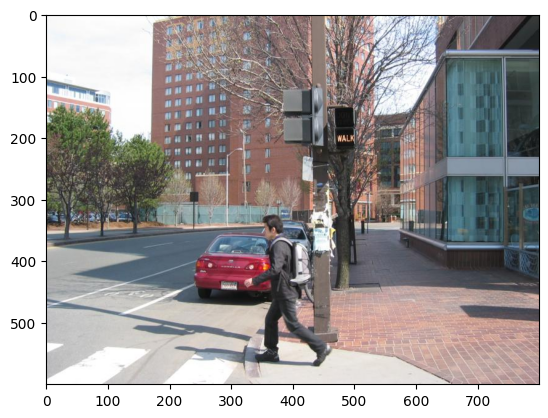

In [9]:
## sample the psg dataset
sample_vg = load_sample(vg_val, index=1)
pprint(sample_vg)
plt.imshow(sample_vg["image"])
plt.show()

In [10]:
def get_class(obj: str):
  cls = obj.split(".")[0]
  return cls

# all_classes = []
# all_predicates = []

# # plot distribution of objects and predicates
# for idx in range(len(vg_val)):
#     sample = load_sample(vg_val, index=idx)
#     objects = ast.literal_eval(sample['objects'])
#     relationships = ast.literal_eval(sample['relationships'])

#     all_classes.extend([get_class(obj['id']) for obj in objects])
#     all_predicates.extend([rel['predicate'] for rel in relationships])



# all_classes = list(set(all_classes))
# all_predicates = list(set(all_predicates))

# print(all_classes[:5])
# print(all_predicates[:5])


In [11]:
print("Total unique classes: ", len(all_classes))
print("Total unique predicates: ", len(all_predicates))

NameError: name 'all_classes' is not defined

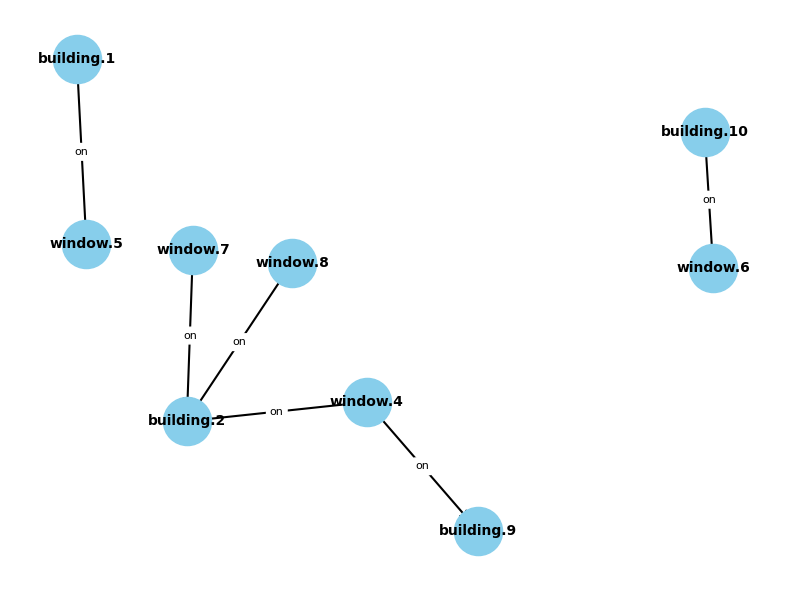

Centrality Score: {'window.4': 0.0, 'building.9': 0.0, 'building.2': 0.0, 'window.7': 0.0, 'window.6': 0.0, 'building.10': 0.0, 'window.8': 0.0, 'window.5': 0.0, 'building.1': 0.0}


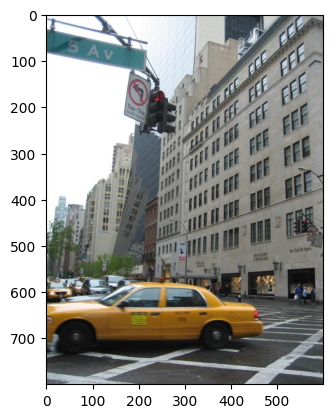

In [11]:
# plot triplets of relationships

def plot_graph(rels):
    # rels: list of {"subject": "...", "predicate": "...", "object": "..."}
    G = nx.DiGraph()
    for rel in rels:
        G.add_edge(rel["subject"], rel["object"], label=rel["predicate"])

    # Layout and figure size
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, k=0.8, seed=0)  # k controls spacing

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_color="#87CEEB", node_size=1200)
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, width=1.5)

    # Node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold",
        horizontalalignment="center",
        verticalalignment="center",
    )

    # Edge labels (predicates)
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        label_pos=0.5,
        rotate=False,  # easier to read
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    centrality_score = nx.betweenness_centrality(G)
    print("Centrality Score:", centrality_score)

sample = load_sample(vg_val, index=500)
plot_graph(ast.literal_eval(sample['relationships']))

plt.imshow(sample["image"])
plt.show()

### Model

##### Load trained model

In [12]:
from peft import PeftModel

base_model_name = "Qwen/Qwen2.5-VL-7B-Instruct"
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    base_model_name,
    torch_dtype="auto",
    device_map="auto"
)

# Load LoRA adapters on top
model = PeftModel.from_pretrained(
    base_model,
    "./grpo-run/checkpoint-50"
)

processor = AutoProcessor.from_pretrained("./grpo-run/checkpoint-50")

print("DEVICE = ", model.device)
print("Model type", type(model))
model.eval()




Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

DEVICE =  cuda:0
Model type <class 'peft.peft_model.PeftModelForCausalLM'>


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear(in_features=1280, out_features=3840, bias=True)
                (proj): Linear(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear(in_features=1280, out_feat

##### Load base model

In [13]:
# model_name = "Qwen/Qwen2-VL-2B-Instruct"
# model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
model_name = "Qwen/Qwen2.5-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_name)
# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     model_name,
#     torch_dtype="auto",
#     device_map="auto"
# )

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("DEVICE = ", model.device)
model.eval()




preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

DEVICE =  cuda:0


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

#### Generation

In [13]:
from pprint import pprint
SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant "
    "first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning "
    "process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., "
    "<think> reasoning process here </think><answer> answer here </answer>"
)

generation_config = {
    'max_new_tokens': 2048,
    # 'temperature': 0.2,
    # 'top_k': 3,
    # 'repetition_penalty': 2.0,
    # 'do_sample': True
}


In [14]:
scene_graph = generate_pipeline(sample, model, processor, generation_config, sys_prompt=SYSTEM_PROMPT)
pprint(scene_graph)

{'_extracted': '{\n'
               '  "objects": [\n'
               '    {"id": "taxi.1", "bbox": [0, 586, 460, 749]},\n'
               '    {"id": "building.1", "bbox": [234, 0, 616, 625]},\n'
               '    {"id": "building.2", "bbox": [0, 398, 150, 587]},\n'
               '    {"id": "building.3", "bbox": [141, 0, 320, 582]},\n'
               '    {"id": "building.4", "bbox": [109, 283, 200, 582]},\n'
               '    {"id": "building.5", "bbox": [199, 382, 240, 582]},\n'
               '    {"id": "street.1", "bbox": [0, 625, 616, 812]},\n'
               '    {"id": "traffic_light.1", "bbox": [200, 167, 277, 263]},\n'
               '    {"id": "sign.1", "bbox": [166, 124, 218, 231]},\n'
               '    {"id": "sign.2", "bbox": [0, 38, 212, 129]},\n'
               '    {"id": "person.1", "bbox": [525, 592, 541, 638]},\n'
               '    {"id": "person.2", "bbox": [541, 595, 555, 638]},\n'
               '    {"id": "person.3", "bbox": [555, 598, 565, 638]},\n

In [ ]:
plot_graph(scene_graph['relationships'])

KeyError: 'relationships'

### Reward Functions

In [15]:
# format reward
def format_reward(pred_json):
  # get keys of json
  keys = list(pred_json.keys())

  if ("objects" in keys) and ("relationships" in keys):
    return 1.0

  if "_raw_text" in keys:
    # text = pred_json["_raw_text"]
    # if re.search(r'"objects"', text, re.I) and re.search(r'"relationships"', text, re.I):
    #     return 1.0
    return 0.0

  if "_extracted" in keys:
    # text = pred_json["_extracted"]
    # if re.search(r'"objects"', text, re.I) and re.search(r'"relationships"', text, re.I):
    #     return 1.0
    return 0.0

  return 0.0

In [16]:
format_reward(scene_graph)

NameError: name 'scene_graph' is not defined

In [16]:
# hard recall
def bbox_iou(b1, b2):
    x1 = max(b1[0], b2[0])
    y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2])
    y2 = min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = max(0, b1[2] - b1[0]) * max(0, b1[3] - b1[1])
    a2 = max(0, b2[2] - b2[0]) * max(0, b2[3] - b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def gt_triplets(gt_graph):
    # gt_graph["objects"] and gt_graph["relationships"]
    id_to_box = {}
    if isinstance(gt_graph["objects"], str):
        gt_graph["objects"] = ast.literal_eval(gt_graph["objects"])

    if isinstance(gt_graph["relationships"], str):
        gt_graph["relationships"] = ast.literal_eval(gt_graph["relationships"])

    for o in gt_graph["objects"]:
        # print("checking gt object ", o)

        oid = o["id"] if isinstance(o, dict) else o[0]
        bbox = o["bbox"] if isinstance(o, dict) else o[1]
        id_to_box[oid] = bbox

    trips = []
    for r in gt_graph["relationships"]:
        trips.append({
            "subject": r["subject"],
            "predicate": r["predicate"],
            "object": r["object"],
        })
    return id_to_box, trips

def soft_match_predicates(pr1, pr2):
  pr1_words = pr1.split()
  pr2_words = pr2.split()
  # filter out empty
  pr1_words = [w for w in pr1_words if w]
  pr2_words = [w for w in pr2_words if w]

  # get common words
  common_words = set(pr1_words) & set(pr2_words)
  if len(common_words) > 0:
    return True
  return False

def hard_recall(pred_graph, gt_graph):
    pred_objs = {o["id"]: o["bbox"] for o in pred_graph.get("objects", [])}
    gt_objs, gt_rels = gt_triplets(gt_graph)

    matched = 0
    total = len(gt_rels)
    if total == 0:
        return 0.0

    for gr in gt_rels:
        ps = get_class(gr["subject"])
        po = get_class(gr["object"])
        pred_match = False
        for pr in pred_graph.get("relationships", []):

            if pr.get("predicate", "") != gr["predicate"] and not (soft_match_predicates(pr.get("predicate", ""), gr["predicate"])):
                continue

            # print("predicate atleast - ", gr['predicate'], " x " , pr.get("predicate", ""))
            # # subject and object
            # print("pred subj ", get_class(pr.get("subject", "")), " gt subj ", ps)
            # print("pred obj ", get_class(pr.get("object", "")), " gt obj ", po)

            if get_class(pr.get("subject", "")) != ps or get_class(pr.get("object", "")) != po:
                continue

            # print("same atleast")
            # if ps in pred_objs and po in pred_objs and ps in gt_objs and po in gt_objs:
            pred_match = True
            break
                # if bbox_iou(pred_objs[ps], gt_objs[ps]) > iou_thr and bbox_iou(pred_objs[po], gt_objs[po]) > iou_thr:
                #     pred_match = True
                #     break
        if pred_match:
            matched += 1

    return matched / total

In [18]:
gt_graph = {"objects": ast.literal_eval(sample["objects"]), "relationships": ast.literal_eval(sample["relationships"])}
pred_graph = scene_graph
print("PREDICTED:")
pprint(pred_graph)
print("GROUND TRUTH:")
pprint(gt_graph)

PREDICTED:
{'_extracted': '{\n'
               '  "objects": [\n'
               '    {"id": "taxi.1", "bbox": [0, 585, 460, 749]},\n'
               '    {"id": "building.1", "bbox": [232, 0, 616, 624]},\n'
               '    {"id": "building.2", "bbox": [0, 397, 150, 586]},\n'
               '    {"id": "building.3", "bbox": [140, 0, 320, 579]},\n'
               '    {"id": "building.4", "bbox": [109, 282, 200, 579]},\n'
               '    {"id": "building.5", "bbox": [199, 381, 240, 579]},\n'
               '    {"id": "street.1", "bbox": [0, 628, 616, 812]},\n'
               '    {"id": "traffic_light.1", "bbox": [200, 166, 276, 262]},\n'
               '    {"id": "sign.1", "bbox": [166, 125, 217, 232]},\n'
               '    {"id": "sign.2", "bbox": [0, 38, 212, 129]},\n'
               '    {"id": "car.1", "bbox": [75, 580, 135, 622]},\n'
               '    {"id": "car.2", "bbox": [52, 586, 80, 620]},\n'
               '    {"id": "car.3", "bbox": [0, 587, 56, 630]},\n'
  

In [19]:
hrd_rec = hard_recall(pred_graph, gt_graph)
print(f"Hard Recall: {hrd_rec}")

Hard Recall: 0.0


In [17]:
# hard recall + relax
from difflib import SequenceMatcher

def name_sim(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

def hard_recall_relax(pred_graph, gt_graph, sim_thr=0.5):
    pred_objs = {o["id"]: o["bbox"] for o in pred_graph.get("objects", [])}
    gt_objs, gt_rels = gt_triplets(gt_graph)

    matched = 0
    total = len(gt_rels)
    if total == 0:
        return 0.0

    for gr in gt_rels:
        gs = get_class(gr["subject"])
        go = get_class(gr["object"])
        gp = gr["predicate"]

        # print("\n== for rl ===" , gr)

        best = False
        for pr in pred_graph.get("relationships", []):
            ps = get_class(pr.get("subject", ""))
            po = get_class(pr.get("object", ""))
            pp = pr.get("predicate", "")

            s_sim = name_sim(ps, gs)
            o_sim = name_sim(po, go)

            if soft_match_predicates(pp, gp):
                p_sim = 1.0
            else:
              p_sim = name_sim(pp, gp)



            if s_sim < sim_thr or o_sim < sim_thr or p_sim < sim_thr:
                continue

            # print(f" sim subj {gs} - {ps}", s_sim)
            # print(f"sim obj {go} - {po}", o_sim)
            # print(f"sim pred {gp} - {pp}", p_sim)


            # if pr["subject"] in pred_objs and pr["object"] in pred_objs and gr["subject"] in gt_objs and gr["object"] in gt_objs:
            #     if bbox_iou(pred_objs[pr["subject"]], gt_objs[gr["subject"]]) > iou_thr and bbox_iou(pred_objs[pr["object"]], gt_objs[gr["object"]]) > iou_thr:
            best = True
            break

        if best:
            matched += 1

    return matched / total

In [21]:
hrd_rec_relax = hard_recall_relax(pred_graph, gt_graph)
print(f"Hard Recall Relax: {hrd_rec_relax}")

Hard Recall Relax: 0.0


In [18]:
# nodes match

def nodes_match_reward(pred_graph, gt_graph):
  pred_objs = [o["id"] for o in pred_graph.get("objects", [])]
  if len(pred_objs) == 0:
    return 0.0

  gt_objs, _ = gt_triplets(gt_graph)
  gt_classes = set([get_class(o_id) for o_id in gt_objs])

  matched = 0
  for p_obj in pred_objs:
    if get_class(p_obj) in gt_classes:
      matched += 1

  return matched / len(pred_objs)

In [23]:
n_match_reward = nodes_match_reward(pred_graph, gt_graph)
print(f"Nodes match reward: {n_match_reward}")

Nodes match reward: 0.0


In [19]:
def total_reward(pred_graph, gt_graph):
  r_format = format_reward(pred_graph)
  r_n_match = nodes_match_reward(pred_graph, gt_graph)
  r_hr = hard_recall(pred_graph, gt_graph)
  r_hrr = hard_recall_relax(pred_graph, gt_graph)
  # if r_format == 0.0:
  #   return 0.0

  total = r_format * 2.0 + r_hr * 0.4 + r_hrr * 0.4 + r_n_match * 0.2
  return {
      "total": total,
      "format": r_format,
      "nodes_match": r_n_match,
      "hard_recall": r_hr,
      "hard_recall_relax": r_hrr
  }

In [20]:
# inds = random.sample(range(len(vg_val)), 50)
inds = list(range(50))
print(inds)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [21]:
all_rewards = []

for i, ind in enumerate(inds):

  print(f"\n========= IND {i} -> {ind} =========\n")
  smpl = load_sample(vg_val, index=ind)

  gt_graph = {"objects": ast.literal_eval(smpl["objects"]), "relationships": ast.literal_eval(smpl["relationships"])}
  pred_graph = generate_pipeline(smpl, model, processor,  generation_config, sys_prompt=SYSTEM_PROMPT)

  print("== FOR == GT - ")
  pprint(gt_graph)
  print(" === PRED ")
  pprint(pred_graph)


  reward = total_reward(pred_graph, gt_graph)
  print("TOTAL: ", reward["total"])
  print("format: ", reward["format"])
  print("nodes_match: ", reward["nodes_match"])
  print("hard_recall: ", reward["hard_recall"])
  print("hard_recall_relax: ", reward["hard_recall_relax"])
  all_rewards.append(reward)



Streaming output truncated to the last 5000 lines.
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'
              '\n'

In [23]:
print(all_rewards)

[{'total': 0.0, 'format': 0.0, 'nodes_match': 0.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 2.1375, 'format': 1.0, 'nodes_match': 0.6875, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 2.036363636363636, 'format': 1.0, 'nodes_match': 0.18181818181818182, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 2.08, 'format': 1.0, 'nodes_match': 0.4, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 2.1176470588235294, 'format': 1.0, 'nodes_match': 0.5882352941176471, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 0.0, 'format': 0.0, 'nodes_match': 0.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 0.0, 'format': 0.0, 'nodes_match': 0.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 0.0, 'format': 0.0, 'nodes_match': 0.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 0.0, 'format': 0.0, 'nodes_match': 0.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.0}, {'total': 2.254761904761905, 'format': 1.0, 'nodes_match': 

In [24]:
n = len(all_rewards)
total_avg = 0.0
format_avg = 0.0
nodes_match_avg = 0.0
hard_recall_avg = 0.0
hard_recall_relax_avg = 0.0
for r in all_rewards:
  total_avg += r['total']
  format_avg += r['format']
  nodes_match_avg += r['nodes_match']
  hard_recall_avg += r['hard_recall']
  hard_recall_relax_avg += r['hard_recall_relax']

total_avg /= n
format_avg /= n
nodes_match_avg /= n
hard_recall_avg /= n
hard_recall_relax_avg /= n

print("Total avg ", total_avg)
print("format avg ", format_avg)
print("nodes_match avg ", nodes_match_avg)
print("hard_recall avg ", hard_recall_avg)
print("hard_recall_relax avg ", hard_recall_relax_avg)



Total avg  1.2341469939245482
format avg  0.56
nodes_match avg  0.26670091870633666
hard_recall avg  0.06750326797385621
hard_recall_relax avg  0.08451375748434574


In [ ]:
for i, rw in enumerate(all_rewards):
  if rw['hard_recall_relax'] > 0.0 or rw['hard_recall'] > 0.0:
    print("IND ", inds[i])
    print(rw)

IND  2114
{'total': 2.2416666666666667, 'format': 1.0, 'nodes_match': 0.5416666666666666, 'hard_recall': 0.3333333333333333, 'hard_recall_relax': 0.0}
IND  3386
{'total': 2.35, 'format': 1.0, 'nodes_match': 1.0, 'hard_recall': 0.0, 'hard_recall_relax': 0.375}
IND  4415
{'total': 2.3, 'format': 1.0, 'nodes_match': 0.8333333333333334, 'hard_recall': 0.0, 'hard_recall_relax': 0.3333333333333333}
IND  117
{'total': 2.457142857142857, 'format': 1.0, 'nodes_match': 0.2857142857142857, 'hard_recall': 0.0, 'hard_recall_relax': 1.0}
IND  3985
{'total': 2.1727272727272724, 'format': 1.0, 'nodes_match': 0.36363636363636365, 'hard_recall': 0.125, 'hard_recall_relax': 0.125}


In [ ]:
pred_graph = {'objects': [{'bbox': [120, 72, 579, 410], 'id': 'building.1'},
             {'bbox': [529, 162, 710, 270], 'id': 'sign.1'},
             {'bbox': [0, 383, 811, 588], 'id': 'sidewalk.1'},
             {'bbox': [630, 404, 700, 492], 'id': 'trash_can.1'},
             {'bbox': [226, 362, 282, 390], 'id': 'people.1'},
             {'bbox': [0, 218, 130, 384], 'id': 'tree.1'},
             {'bbox': [0, 0, 750, 220], 'id': 'sky.1'}],
 'relationships': [{'object': 'sign.1',
                    'predicate': 'has',
                    'subject': 'building.1'},
                   {'object': 'sidewalk.1',
                    'predicate': 'standing on',
                    'subject': 'people.1'},
                   {'object': 'sidewalk.1',
                    'predicate': 'is near',
                    'subject': 'trash_can.1'}]}

smp = load_sample(vg_val, index=117)
gt_graph = {"objects": ast.literal_eval(smp["objects"]), "relationships": ast.literal_eval(smp["relationships"])}


print(hard_recall_relax(pred_graph, gt_graph))


 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
 sim subj building - building 1.0
sim obj window - sign 0.4
sim pred has - has 1.0
1.0
